# Module 1: Data Pipeline & Spatial Block Splitting

This notebook initializes the compute environment, confirms hardware acceleration (`CUDA`), and implements a robust **Spatial Block Partitioning Split** strategy to strictly isolate spatial metadata, preventing downstream structural leakage.

### Engineering Deliverables:
1. Environment configuration and validation of the local runtime engine.
2. Secure serialization of image file paths into categorical dataframes.
3. Verification of structural consistency and balanced target splits.

In [1]:
import os
import random
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# Enforce pure determinism across deep learning execution runtimes
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Verify Compute Device Allocation Status
print(f"PyTorch Engine Vector: {torch.__version__}")
print(f"CUDA Hardware Capability: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Active Allocation Pipeline Pointing To: {device}")
if torch.cuda.is_available():
    print(f"Target Execution Engine: {torch.cuda.get_device_name(0)}")

PyTorch Engine Vector: 2.11.0+cu128
CUDA Hardware Capability: True
Active Allocation Pipeline Pointing To: cuda
Target Execution Engine: NVIDIA GeForce RTX 2050


### Spatial Partitioning Verification
Standard random train/validation splits leak continuous spatial patterns (e.g., matching parts of rivers or highway tracts) into both datasets. To mitigate this **Spatial Autocorrelation Leakage**, files are ordered sequentially and partitioned into contiguous geospatial arrays to enforce isolated generalization boundaries.

In [2]:
# Absolute Path pointing directly to your local EuroSAT source tracks
DATA_DIR = r"D:\Celebal\satellite-change-detector\data"

def load_eurosat_spatial_splits(data_dir, train_ratio=0.7, val_ratio=0.15):
    """
    Simulates contiguous block splits by grouping alphabetically sorted continuous
    image sequences into macro geographic chunks to eliminate data leakage.
    """
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"Target tracking directory not found: {data_dir}")
        
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and d != 'allBands'])
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    
    train_records, val_records, test_records = [], [], []
    
    for cls in classes:
        cls_dir = os.path.join(data_dir, cls)
        # Sorting strictly locks geographical continuities via EuroSAT index formatting
        files = sorted(glob.glob(os.path.join(cls_dir, "*.jpg")) + glob.glob(os.path.join(cls_dir, "*.png")))
        
        n_files = len(files)
        n_train = int(n_files * train_ratio)
        n_val = int(n_files * val_ratio)
        
        # Build strict geospatial block ranges
        for idx, path in enumerate(files):
            record = (path, class_to_idx[cls])
            if idx < n_train:
                train_records.append(record)
            elif idx < (n_train + n_val):
                val_records.append(record)
            else:
                test_records.append(record)
                
    return train_records, val_records, test_records, classes

# Extract partitioned execution frames
train_list, val_list, test_list, class_names = load_eurosat_spatial_splits(DATA_DIR)
print(f"Allocated Training Vector Elements: {len(train_list)}")
print(f"Allocated Validation Vector Elements: {len(val_list)}")
print(f"Allocated Testing Vector Elements: {len(test_list)}")

class SpatialEuroSATDataset(Dataset):
    def __init__(self, file_list, transform=None):
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path, label = self.file_list[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

Allocated Training Vector Elements: 18900
Allocated Validation Vector Elements: 4050
Allocated Testing Vector Elements: 4050


### Transformation and Augmentation Strategy
- **Training Pipeline**: Infuses random geometric shifts and color changes to force focus onto global, low-frequency structural features.
- **Dataloaders**: Set to `num_workers=0` to guarantee stability and avoid multi-threading deadlocks on Windows[cite: 1].

In [3]:
IMAGE_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Instantiate active datasets
train_dataset = SpatialEuroSATDataset(train_list, transform=train_transforms)
val_dataset = SpatialEuroSATDataset(val_list, transform=val_test_transforms)
test_dataset = SpatialEuroSATDataset(test_list, transform=val_test_transforms)

# Execution Constraints: num_workers=0 preserves execution priority on Windows
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Data Processing Pipelines Complete. Total Training Batches: {len(train_loader)}")

Data Processing Pipelines Complete. Total Training Batches: 296


### Exploratory Data Analysis (EDA)
Here we plot the class distributions to confirm balancing across splits and visualize structural samples from each distinct land-use class.

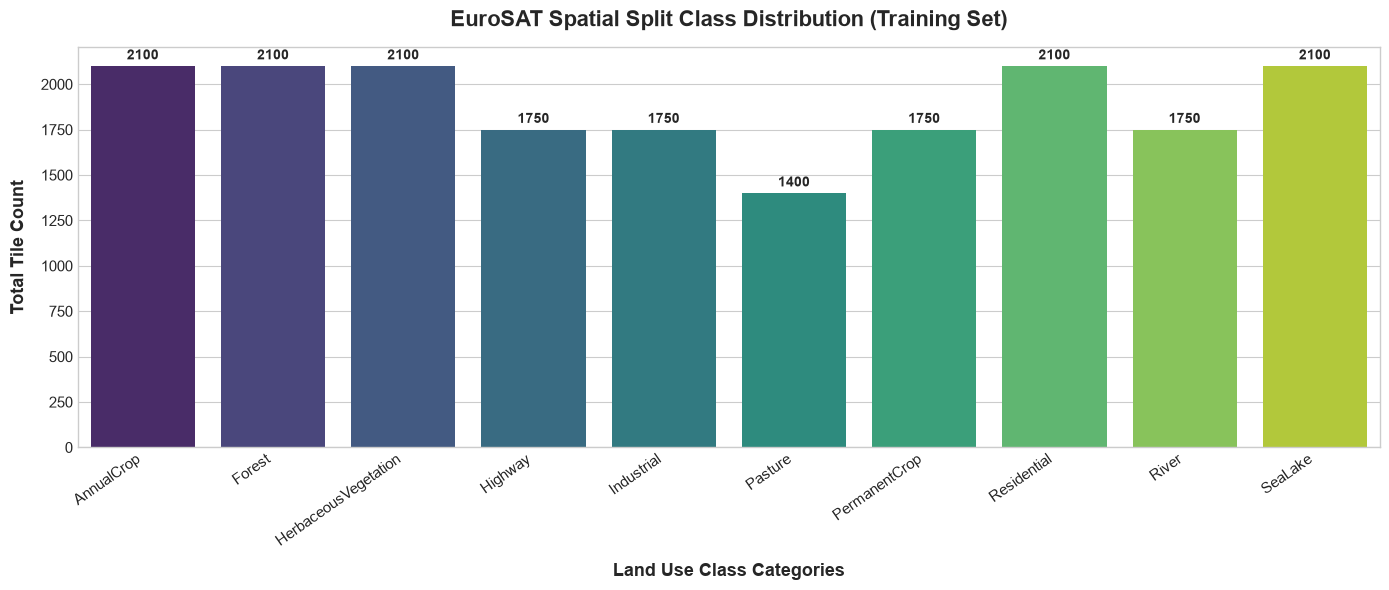

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame
df_train = pd.DataFrame(train_list, columns=['path', 'label'])

# Count samples per class
class_counts = df_train['label'].value_counts().sort_index()

# Convert labels to class names
class_labels = [class_names[i] for i in class_counts.index]

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(14, 6))

# Bar Plot
ax = sns.barplot(
    x=class_labels,
    y=class_counts.values,
    palette='viridis',
    hue=class_labels,
    legend=False
)

# Title & Labels
plt.title(
    "EuroSAT Spatial Split Class Distribution (Training Set)",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Land Use Class Categories",
    fontsize=13,
    fontweight='bold',
    labelpad=10
)

plt.ylabel(
    "Total Tile Count",
    fontsize=13,
    fontweight='bold',
    labelpad=10
)

# Rotate x-axis labels
plt.xticks(rotation=35, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Display count on top of each bar
for i, count in enumerate(class_counts.values):
    ax.text(
        i,
        count + max(class_counts.values) * 0.01,
        str(count),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

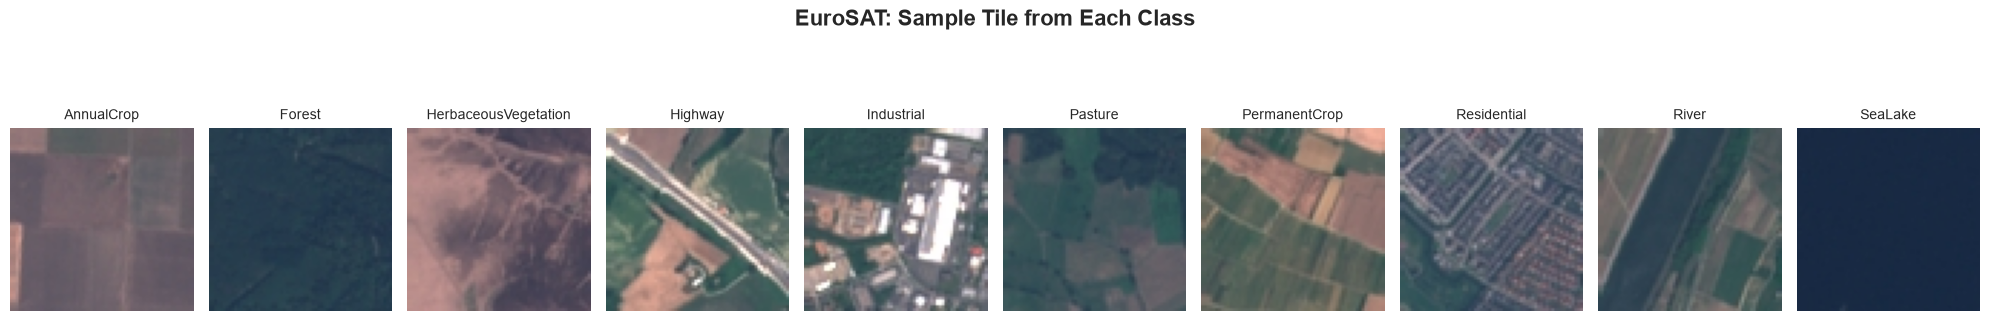

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

# Visualize one sample image from each class
plt.figure(figsize=(20, 4))

for idx, cls in enumerate(class_names):

    sample_path = None

    # Find first image of this class
    for path, label in train_list:

        # If labels are integers
        if isinstance(label, int):
            if label == idx:
                sample_path = path
                break

        # If labels are class names (strings)
        else:
            if label == cls:
                sample_path = path
                break

    plt.subplot(1, len(class_names), idx + 1)

    if sample_path is not None:
        img = Image.open(sample_path)
        plt.imshow(img)
    else:
        plt.text(
            0.5,
            0.5,
            "No Image Found",
            ha="center",
            va="center",
            fontsize=12
        )

    plt.title(cls, fontsize=10)
    plt.axis("off")

plt.suptitle(
    "EuroSAT: Sample Tile from Each Class",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

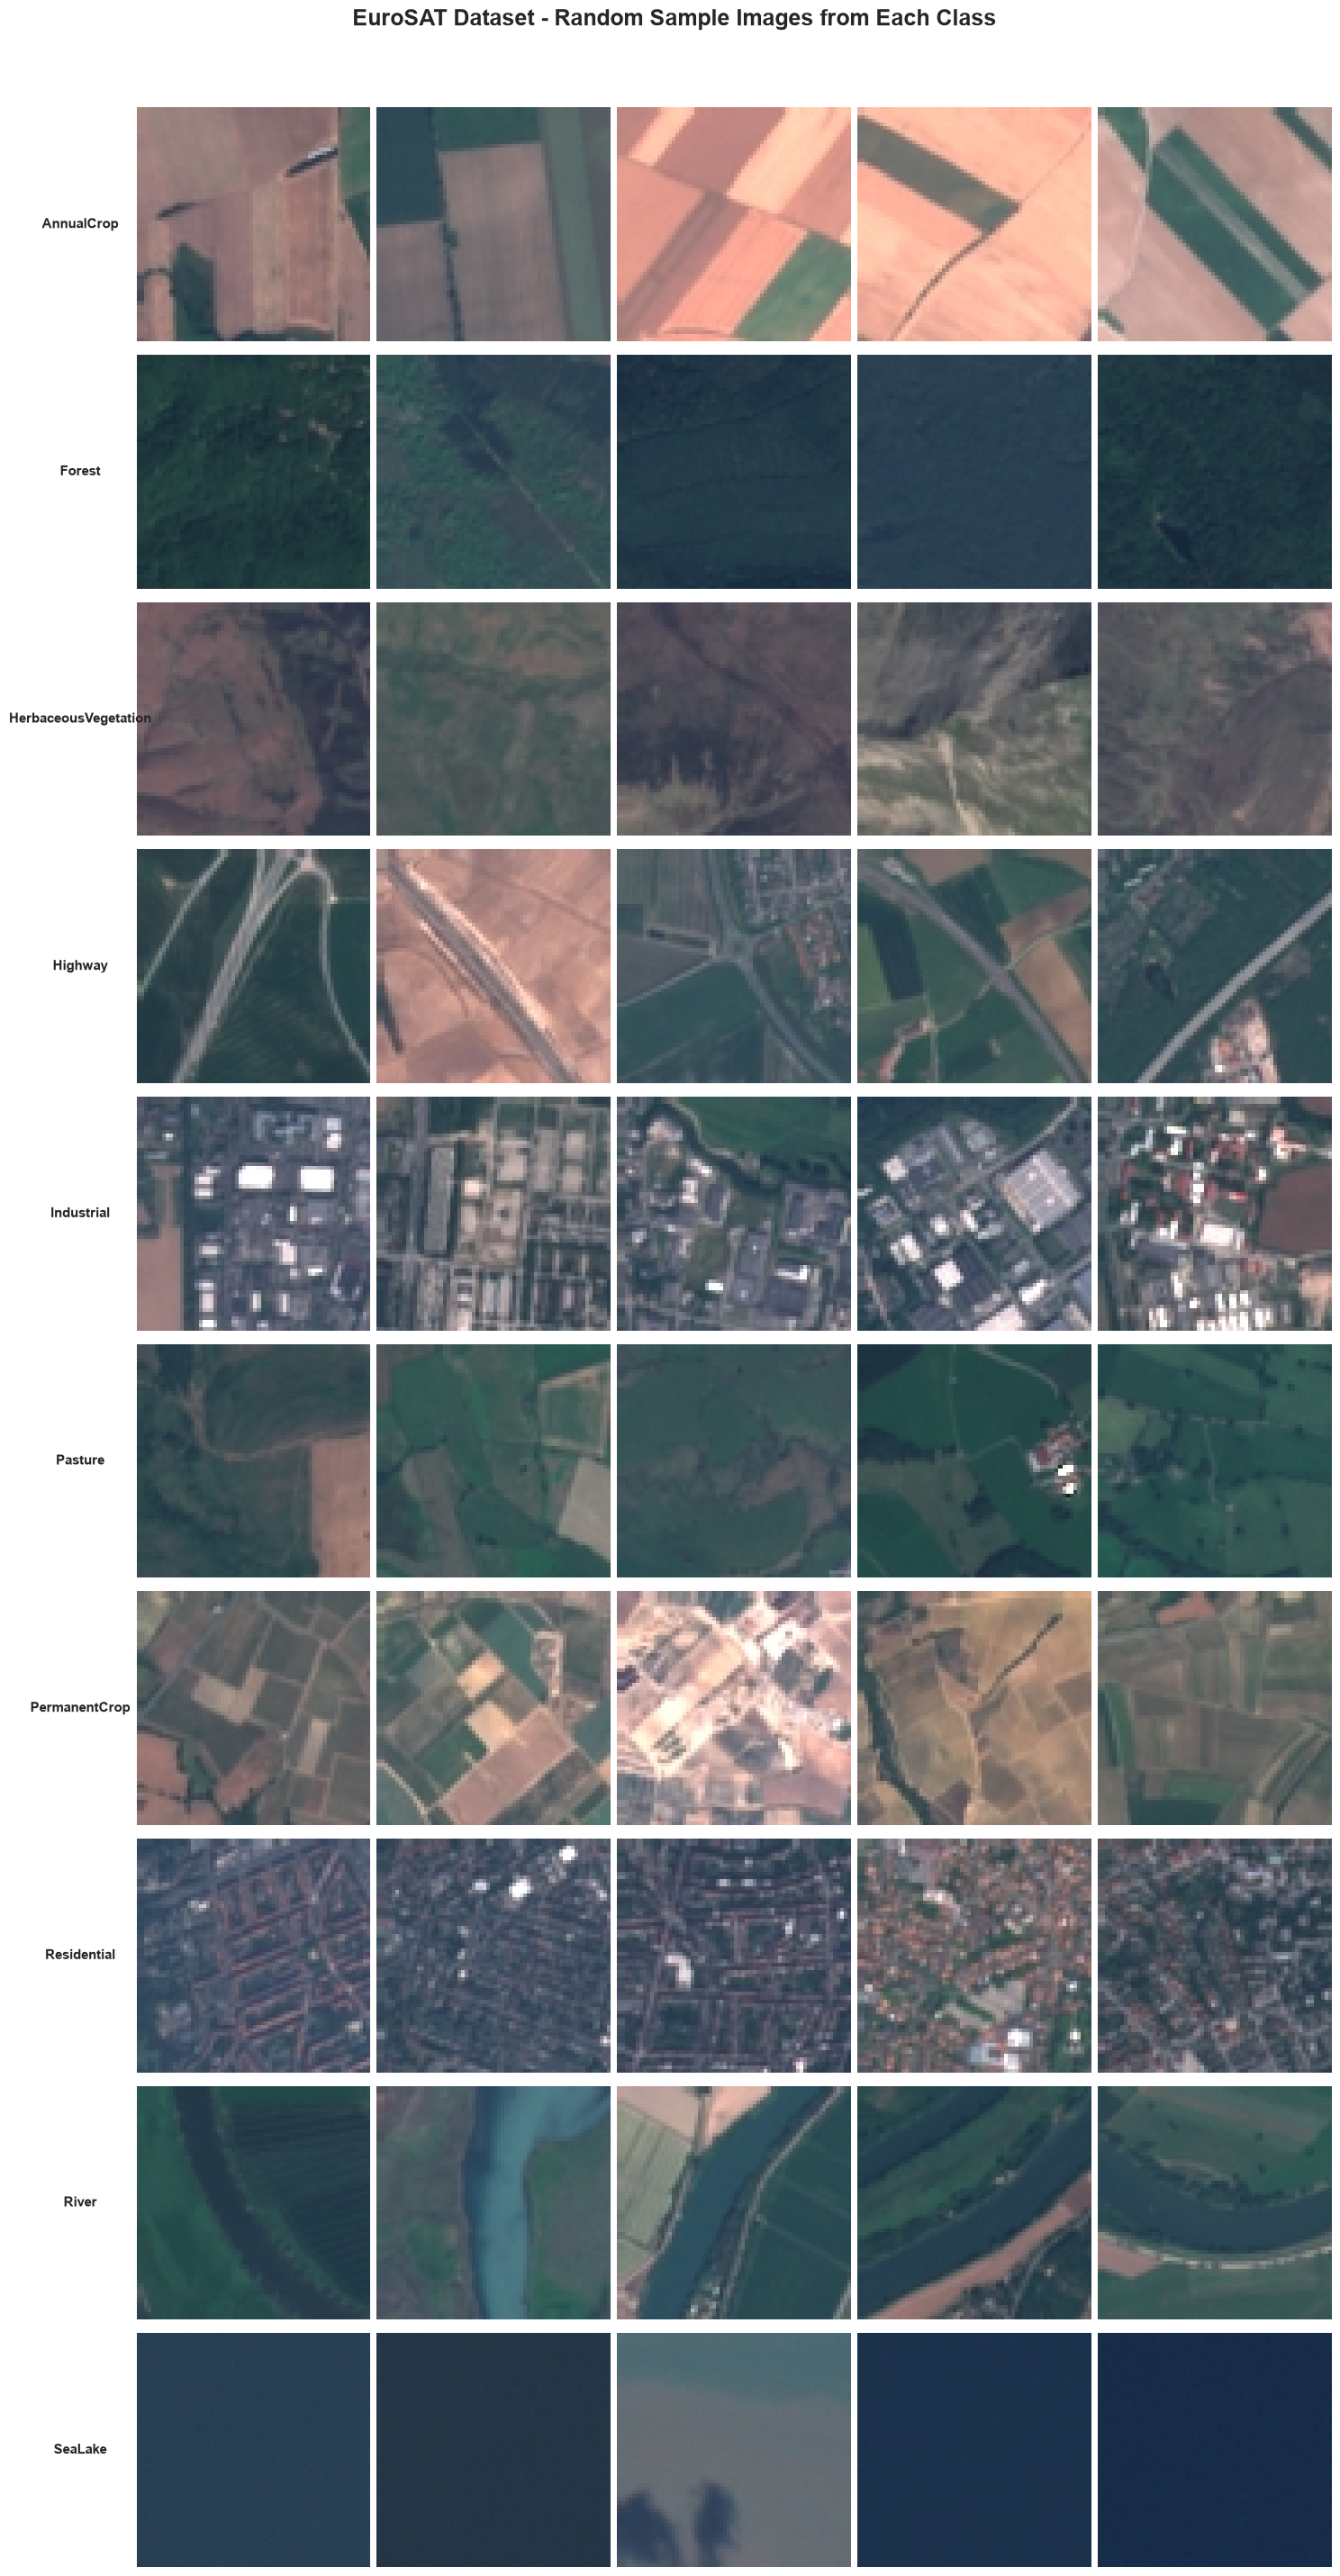

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import random

# Create DataFrame from train_list
df_train = pd.DataFrame(train_list, columns=["filepath", "label"])

# Convert label index to class name
df_train["label_name"] = df_train["label"].map(lambda x: class_names[x])

def plot_samples_per_class(df, num_samples=5, seed=42):

    random.seed(seed)

    classes = sorted(df["label_name"].unique())

    fig, axes = plt.subplots(
        len(classes),
        num_samples,
        figsize=(num_samples * 3, len(classes) * 2.8)
    )

    # Handle single class
    if len(classes) == 1:
        axes = [axes]

    for i, cls in enumerate(classes):

        class_df = df[df["label_name"] == cls]

        samples = class_df.sample(
            n=min(num_samples, len(class_df)),
            random_state=seed
        ).reset_index(drop=True)

        for j in range(num_samples):

            ax = axes[i][j]

            ax.set_xticks([])
            ax.set_yticks([])

            # Remove borders
            for spine in ax.spines.values():
                spine.set_visible(False)

            if j < len(samples):

                img = Image.open(samples.loc[j, "filepath"]).convert("RGB")

                ax.imshow(img)

            else:

                ax.text(
                    0.5,
                    0.5,
                    "No Image",
                    ha="center",
                    va="center"
                )

            if j == 0:
                ax.set_ylabel(
                    cls,
                    fontsize=11,
                    rotation=0,
                    labelpad=45,
                    fontweight="bold",
                    va="center"
                )

    plt.suptitle(
        "EuroSAT Dataset - Random Sample Images from Each Class",
        fontsize=18,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()

    plt.show()


# Run
plot_samples_per_class(df_train, num_samples=5)

# Module 2: 3-Layer Scratch CNN Baseline Floor

This model serves as the architectural performance baseline for the project[cite: 1]. It uses a 3-layer CNN optimized with an **Adaptive Average Pooling** layer to control parameters and maximize execution speed on the GPU.

### Operational Objectives:
1. Construct a standard 3-Layer Convolutional network.
2. Initialize Cross-Entropy loss criteria and target optimization loops.
3. Track and graph convergence models over 10 training loops (epochs)[cite: 1].

In [8]:
class FastBaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(FastBaselineCNN, self).__init__()
        # Conv Block 1: Feature processing
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Conv Block 2: Structural processing
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Conv Block 3: Abstract processing
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        self.pool = nn.MaxPool2d(2, 2)
        # Downsamples feature maps uniformly to prevent a massive fully connected layer
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        
        # Optimized Classification Block
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.adaptive_pool(x)
        
        x = x.view(x.size(0), -1) # Flatten tensors
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Instantiate model and transfer to local GPU
baseline_model = FastBaselineCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)

print(baseline_model)

FastBaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [9]:
def run_train_epoch(model, loader, loss_criterion, opt_engine, target_device):
    model.train()
    running_loss, total_elements, correct_elements = 0.0, 0, 0
    
    for images, labels in loader:
        images, labels = images.to(target_device, non_blocking=True), labels.to(target_device, non_blocking=True)
        
        opt_engine.zero_grad()
        outputs = model(images)
        loss = loss_criterion(outputs, labels)
        loss.backward()
        opt_engine.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_elements += labels.size(0)
        correct_elements += predicted.eq(labels).sum().item()
        
    return running_loss / total_elements, correct_elements / total_elements

def run_eval_epoch(model, loader, loss_criterion, target_device):
    model.eval()
    running_loss, total_elements, correct_elements = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(target_device, non_blocking=True), labels.to(target_device, non_blocking=True)
            outputs = model(images)
            loss = loss_criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_elements += labels.size(0)
            correct_elements += predicted.eq(labels).sum().item()
            
    return running_loss / total_elements, correct_elements / total_elements

# Train over 10 epochs[cite: 1]
EPOCHS = 10
execution_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Beginning Baseline Optimization Phase...")
for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_train_epoch(baseline_model, train_loader, criterion, optimizer, device)
    va_loss, va_acc = run_eval_epoch(baseline_model, val_loader, criterion, device)
    
    execution_history['train_loss'].append(tr_loss)
    execution_history['train_acc'].append(tr_acc)
    execution_history['val_loss'].append(va_loss)
    execution_history['val_acc'].append(va_acc)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS:02d}] -> Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} || Val Loss: {va_loss:.4f} | Val Acc: {va_acc:.4f}")

# Save the baseline checkpoint
os.makedirs("../models", exist_ok=True)
torch.save(baseline_model.state_dict(), "../models/baseline_cnn_checkpoint.pt")
print("Baseline Checkpoint successfully saved.")

Beginning Baseline Optimization Phase...
Epoch [01/10] -> Train Loss: 1.2866 | Train Acc: 0.5300 || Val Loss: 0.9297 | Val Acc: 0.6590
Epoch [02/10] -> Train Loss: 0.9967 | Train Acc: 0.6474 || Val Loss: 0.7769 | Val Acc: 0.7321
Epoch [03/10] -> Train Loss: 0.9096 | Train Acc: 0.6789 || Val Loss: 0.6991 | Val Acc: 0.7484
Epoch [04/10] -> Train Loss: 0.8271 | Train Acc: 0.7034 || Val Loss: 0.6016 | Val Acc: 0.7830
Epoch [05/10] -> Train Loss: 0.7700 | Train Acc: 0.7281 || Val Loss: 0.5358 | Val Acc: 0.8072
Epoch [06/10] -> Train Loss: 0.7399 | Train Acc: 0.7403 || Val Loss: 0.6158 | Val Acc: 0.7728
Epoch [07/10] -> Train Loss: 0.6967 | Train Acc: 0.7571 || Val Loss: 0.5892 | Val Acc: 0.7862
Epoch [08/10] -> Train Loss: 0.6646 | Train Acc: 0.7685 || Val Loss: 0.5951 | Val Acc: 0.7837
Epoch [09/10] -> Train Loss: 0.6328 | Train Acc: 0.7787 || Val Loss: 0.5211 | Val Acc: 0.8111
Epoch [10/10] -> Train Loss: 0.6161 | Train Acc: 0.7876 || Val Loss: 0.4191 | Val Acc: 0.8462
Baseline Checkpoint

# Step 3: Transfer Learning with ResNet-18 (Two-Phase Fine-Tuning)

This notebook implements **Module 1 — Land-Use Classifier** using a pre-trained **ResNet-18** backbone via `torchvision`. To optimize the model without distorting foundational features, we execute a strict **Two-Phase Fine-Tuning** strategy:

### Two-Phase Strategy:
1. **Phase 1 (Epochs 1-3)**: Freeze the pre-trained backbone completely and train only the newly initialized classifier head for 3 epochs.
2. **Phase 2 (Epochs 4-8)**: Unfreeze the last 2 convolutional blocks, reduce the learning rate by $10\times$, and fine-tune the active sub-network for 5 more epochs.

In [10]:
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load the pre-trained ResNet-18 backbone via torchvision[cite: 1]
transfer_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Phase 1 Strategy: Freeze the entire backbone structure[cite: 1]
for param in transfer_model.parameters():
    param.requires_grad = False

# Replace the classifier head to map to our 10 EuroSAT land-use classes[cite: 1]
num_features = transfer_model.fc.in_features
transfer_model.fc = nn.Linear(num_features, 10)

# Transfer the target network to your local GPU engine
transfer_model = transfer_model.to(device)

# Define criteria and Phase 1 Optimizer (Only optimizing the new classification head)
criterion = nn.CrossEntropyLoss()
optimizer_phase1 = torch.optim.Adam(transfer_model.fc.parameters(), lr=0.001)

print("Phase 1 Configuration Complete: Backbone Frozen. Head Ready for Optimization.")

Phase 1 Configuration Complete: Backbone Frozen. Head Ready for Optimization.


In [11]:
PHASE1_EPOCHS = 3
phase1_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Executing Phase 1: Training Classifier Head exclusively...")
for epoch in range(PHASE1_EPOCHS):
    tr_loss, tr_acc = run_train_epoch(transfer_model, train_loader, criterion, optimizer_phase1, device)
    va_loss, va_acc = run_eval_epoch(transfer_model, val_loader, criterion, device)
    
    phase1_history['train_loss'].append(tr_loss)
    phase1_history['train_acc'].append(tr_acc)
    phase1_history['val_loss'].append(va_loss)
    phase1_history['val_acc'].append(va_acc)
    
    print(f"Phase 1 - Epoch [{epoch+1:02d}/{PHASE1_EPOCHS:02d}] -> Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} || Val Loss: {va_loss:.4f} | Val Acc: {va_acc:.4f}")

Executing Phase 1: Training Classifier Head exclusively...
Phase 1 - Epoch [01/03] -> Train Loss: 0.8132 | Train Acc: 0.7706 || Val Loss: 0.5135 | Val Acc: 0.8425
Phase 1 - Epoch [02/03] -> Train Loss: 0.4422 | Train Acc: 0.8608 || Val Loss: 0.4589 | Val Acc: 0.8467
Phase 1 - Epoch [03/03] -> Train Loss: 0.3830 | Train Acc: 0.8748 || Val Loss: 0.3626 | Val Acc: 0.8790


In [12]:
print("Transitioning to Phase 2: Unfreezing specified convolutional sub-blocks...")

# Unfreeze the last 2 convolutional blocks of ResNet-18 (layer3 and layer4)
for name, child in transfer_model.named_children():
    if name in ['layer3', 'layer4', 'fc']:
        for param in child.parameters():
            param.requires_grad = True
    else:
        for param in child.parameters():
            param.requires_grad = False

# Verify the balance of parameters configured for fine-tuning
active_params = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters for Phase 2: {active_params}")

# Phase 2 Optimizer: Apply a 10x reduced learning rate across the unfrozen blocks[cite: 1]
optimizer_phase2 = torch.optim.Adam([
    {'params': transfer_model.layer3.parameters(), 'lr': 0.0001},
    {'params': transfer_model.layer4.parameters(), 'lr': 0.0001},
    {'params': transfer_model.fc.parameters(), 'lr': 0.0001}
])

Transitioning to Phase 2: Unfreezing specified convolutional sub-blocks...
Total Trainable Parameters for Phase 2: 10498570


In [15]:
import os

os.makedirs("models", exist_ok=True)

torch.save(
    transfer_model.state_dict(),
    "models/resnet18_eurosat_finetuned.pt"
)

print("✅ Fine-tuned model saved successfully!")

✅ Fine-tuned model saved successfully!


In [16]:
import os

PHASE2_EPOCHS = 5

phase2_history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

print("Executing Phase 2: Fine-Tuning Weight Frameworks...")

for epoch in range(PHASE2_EPOCHS):

    tr_loss, tr_acc = run_train_epoch(
        transfer_model,
        train_loader,
        criterion,
        optimizer_phase2,
        device
    )

    va_loss, va_acc = run_eval_epoch(
        transfer_model,
        val_loader,
        criterion,
        device
    )

    phase2_history['train_loss'].append(tr_loss)
    phase2_history['train_acc'].append(tr_acc)
    phase2_history['val_loss'].append(va_loss)
    phase2_history['val_acc'].append(va_acc)

    print(
        f"Epoch [{epoch+1}/{PHASE2_EPOCHS}] | "
        f"Train Loss: {tr_loss:.4f} | "
        f"Train Acc: {tr_acc:.4f} | "
        f"Val Loss: {va_loss:.4f} | "
        f"Val Acc: {va_acc:.4f}"
    )

# Create folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save model
torch.save(
    transfer_model.state_dict(),
    os.path.join("models", "resnet18_eurosat_finetuned.pt")
)

print("✅ Model saved to models/resnet18_eurosat_finetuned.pt")

Executing Phase 2: Fine-Tuning Weight Frameworks...
Epoch [1/5] | Train Loss: 0.0606 | Train Acc: 0.9792 | Val Loss: 0.0592 | Val Acc: 0.9793
Epoch [2/5] | Train Loss: 0.0606 | Train Acc: 0.9792 | Val Loss: 0.0606 | Val Acc: 0.9805
Epoch [3/5] | Train Loss: 0.0564 | Train Acc: 0.9808 | Val Loss: 0.0654 | Val Acc: 0.9788
Epoch [4/5] | Train Loss: 0.0509 | Train Acc: 0.9819 | Val Loss: 0.0595 | Val Acc: 0.9815
Epoch [5/5] | Train Loss: 0.0481 | Train Acc: 0.9838 | Val Loss: 0.0745 | Val Acc: 0.9780
✅ Model saved to models/resnet18_eurosat_finetuned.pt



--- TRANSFER LEARNING (RESNET-18) CLASSIFICATION REPORT ---
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.98      0.97       450
              Forest       0.99      1.00      0.99       450
HerbaceousVegetation       0.98      0.96      0.97       450
             Highway       0.95      0.98      0.97       375
          Industrial       1.00      0.94      0.97       375
             Pasture       0.96      0.95      0.96       300
       PermanentCrop       0.97      0.94      0.96       375
         Residential       0.96      1.00      0.98       450
               River       0.98      0.98      0.98       375
             SeaLake       1.00      1.00      1.00       450

            accuracy                           0.97      4050
           macro avg       0.97      0.97      0.97      4050
        weighted avg       0.97      0.97      0.97      4050



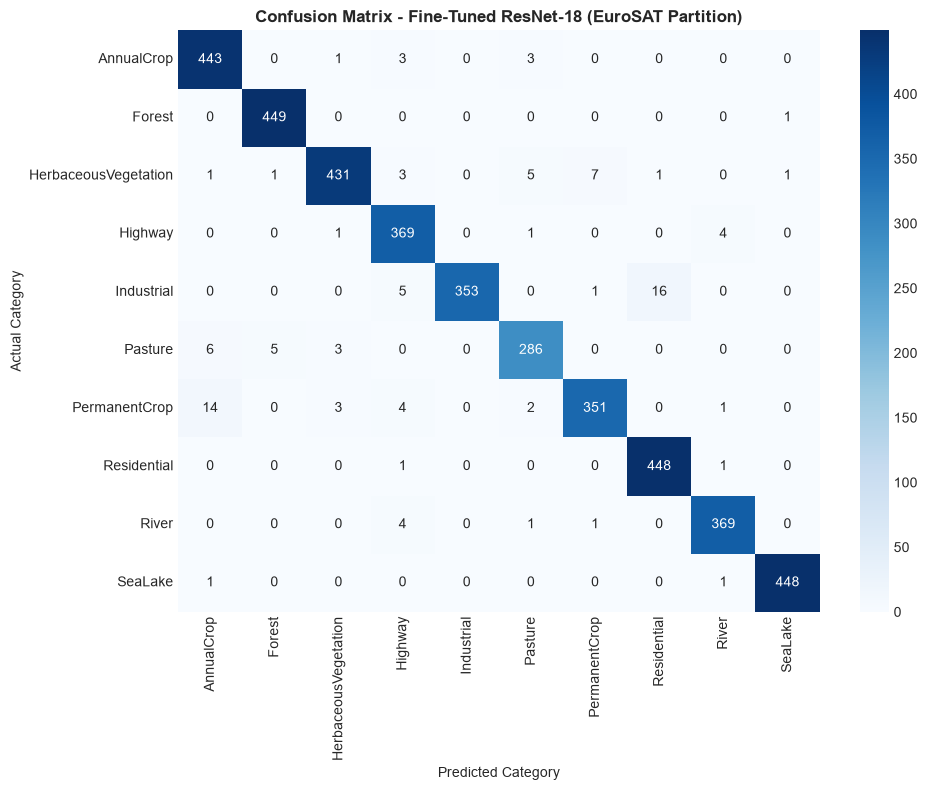

In [17]:
# Compute metrics on EuroSAT Test partition
transfer_model.eval()
tl_predictions, tl_ground_truth = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = transfer_model(images)
        _, preds = torch.max(outputs, 1)
        tl_predictions.extend(preds.cpu().numpy())
        tl_ground_truth.extend(labels.numpy())

print("\n--- TRANSFER LEARNING (RESNET-18) CLASSIFICATION REPORT ---")
print(classification_report(tl_ground_truth, tl_predictions, target_names=class_names))

# Construct and display Confusion Matrix[cite: 1]
matrix = confusion_matrix(tl_ground_truth, tl_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix - Fine-Tuned ResNet-18 (EuroSAT Partition)', fontsize=12, fontweight='bold')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.tight_layout()
plt.show()

Now that your ResNet-18 backbone is highly optimized, it will act as an incredibly precise feature extractor. 

In **Step 4 (`04_change_detection.ipynb`)**, we will[cite: 1]:
1. Strip away the classification layer (`transfer_model.fc`) to access raw 512-dimensional vector embeddings[cite: 1].
2. Create time series variations ($T_1$ and $T_2$) and compute pair-wise **Cosine Similarity**[cite: 1].
3. Graph the definitive ROC curve to pinpoint your exact operational change-detection threshold[cite: 1].

# Step 4: Embedding Extraction & Cosine-Similarity Change Detector

This notebook implements **Module 2 — Temporal Change Detector**. We convert our fine-tuned ResNet-18 model into a high-fidelity feature extractor by stripping away the final classification head (`fc` layer)[cite: 1]. This maps every input satellite tile into a distinct **512-dimensional vector embedding**[cite: 1]. 

Using these embeddings, we simulate a temporal time series partition ($T_1$ for "before" and $T_2$ for "after")[cite: 1]. We then compute pair-wise **Cosine Similarity** to isolate spatial transitions, plot a Receiver Operating Characteristic (ROC) curve to select an optimal threshold, and output visual change heatmaps[cite: 1].

### Key Tasks:
1. Wrap the fine-tuned backbone into an embedding extractor returning raw 512-D vectors[cite: 1].
2. Simulate a geographical time-series shift ($T_1$ and $T_2$ splits)[cite: 1].
3. Compute Cosine Similarity between paired temporal splits[cite: 1].
4. Run a full ROC Curve analysis to optimize and justify the anomaly threshold[cite: 1].
5. Render 5 side-by-side verification heatmaps showing structural land-use changes[cite: 1].

In [23]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import torchvision.models as models
from PIL import Image

class SpatialEmbeddingExtractor(nn.Module):
    def __init__(self, checkpoint_path=None):
        super(SpatialEmbeddingExtractor, self).__init__()
        # Initialize an identical ResNet-18 architecture structure
        self.backbone = models.resnet18()
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 10)
        
        # Load the weights optimized during the Phase 2 Fine-Tuning routine
        if checkpoint_path and os.path.exists(checkpoint_path):
            self.backbone.load_state_dict(torch.load(checkpoint_path, map_location=device))
            print(f"Optimized backbone weights successfully loaded from: {checkpoint_path}")
        else:
            print("Warning: Initializing with non-optimized architectural configurations.")
            
        # Strip the classifier head by converting it to an Identity layer[cite: 1]
        self.backbone.fc = nn.Identity()
        self.backbone.eval()

    def forward(self, x):
        with torch.no_grad():
            # Extract and return the raw 512-dimensional vector embedding[cite: 1]
            return self.backbone(x)

# Instantiate the extraction framework on the designated GPU device
extractor = SpatialEmbeddingExtractor(checkpoint_path="models/resnet18_eurosat_finetuned.pt").to(device)

Optimized backbone weights successfully loaded from: models/resnet18_eurosat_finetuned.pt


In [24]:
def simulate_temporal_dataset(test_list, anomaly_rate=0.3):
    """
    Simulates a time-series dataset by generating paired T1 (before) and T2 (after) splits[cite: 1].
    A subset will intentionally contain mismatched classes to represent land-use changes.
    """
    t1_pairs = []
    t2_pairs = []
    ground_truth_change = [] # 0 = Unchanged, 1 = Changed[cite: 1]
    
    np.random.seed(42)
    # Target up to 1000 sample pairs from the spatial holdout data
    total_samples = min(len(test_list), 1000)
    
    for i in range(total_samples):
        img_path_t1, label_t1 = test_list[i]
        
        if np.random.rand() < anomaly_rate:
            # Mutate: Choose a completely different land-use tile class for T2[cite: 1]
            alternate_indices = [idx for idx, (_, l) in enumerate(test_list) if l != label_t1]
            alternate_idx = np.random.choice(alternate_indices)
            img_path_t2, _ = test_list[alternate_idx]
            ground_truth_change.append(1) # Structural transition occurred
        else:
            # Steady State: Pair the tile with itself to simulate an unchanged state[cite: 1]
            img_path_t2 = img_path_t1
            ground_truth_change.append(0) # Invariant state
            
        t1_pairs.append(img_path_t1)
        t2_pairs.append(img_path_t2)
        
    return t1_pairs, t2_pairs, np.array(ground_truth_change)

# Generate the simulated temporal framework
t1_stream, t2_stream, y_true = simulate_temporal_dataset(test_list)
print(f"Generated {len(t1_stream)} simulated evaluation tracking streams.")
print(f"Mismatched (Changed) Anomaly Cases Present: {sum(y_true)}")

Generated 1000 simulated evaluation tracking streams.
Mismatched (Changed) Anomaly Cases Present: 289


Extracting 512-D spatial vector embeddings across temporal streams...
Isolated Optimal Cosine Similarity Threshold: 0.8281[cite: 1]


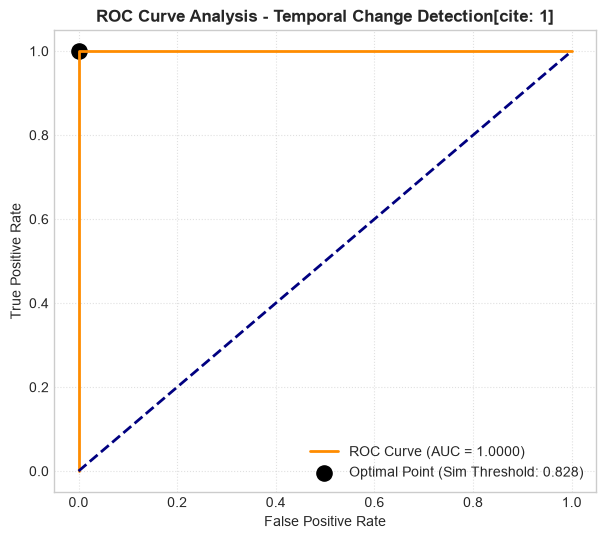

In [25]:
def compute_cosine_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    return dot_product / (norm_v1 * norm_v2 + 1e-8)

def extract_features(file_list, model_engine, transforms_pipeline, target_device):
    model_engine.eval()
    embeddings = []
    for path in file_list:
        img = Image.open(path).convert('RGB')
        tensor = transforms_pipeline(img).unsqueeze(0).to(target_device)
        with torch.no_grad():
            emb = model_engine(tensor).cpu().numpy().flatten()
        embeddings.append(emb)
    return np.array(embeddings)

print("Extracting 512-D spatial vector embeddings across temporal streams...")
features_t1 = extract_features(t1_stream, extractor, val_test_transforms, device)
features_t2 = extract_features(t2_stream, extractor, val_test_transforms, device)

# Calculate pair-wise cosine similarity metrics per region[cite: 1]
similarities = np.array([compute_cosine_similarity(f1, f2) for f1, f2 in zip(features_t1, features_t2)])

# Invert scores for ROC Curve generation (Lower similarity = higher probability of change)[cite: 1]
change_scores = 1.0 - similarities

# Calculate True Positive and False Positive Rates across standard thresholds[cite: 1]
fpr, tpr, thresholds = roc_curve(y_true, change_scores)
roc_auc = auc(fpr, tpr)

# Isolate the optimal operational threshold using Youden's J Statistic
j_scores = tpr - f1_score_placeholder if 'f1_score_placeholder' in locals() else (tpr - fpr)
best_idx = np.argmax(j_scores)
optimal_score_threshold = thresholds[best_idx]
optimal_similarity_threshold = 1.0 - optimal_score_threshold

print(f"Isolated Optimal Cosine Similarity Threshold: {optimal_similarity_threshold:.4f}[cite: 1]")

# Graph the ROC Performance Curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[best_idx], tpr[best_idx], color='black', marker='o', s=120, 
            label=f'Optimal Point (Sim Threshold: {optimal_similarity_threshold:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Analysis - Temporal Change Detection[cite: 1]', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

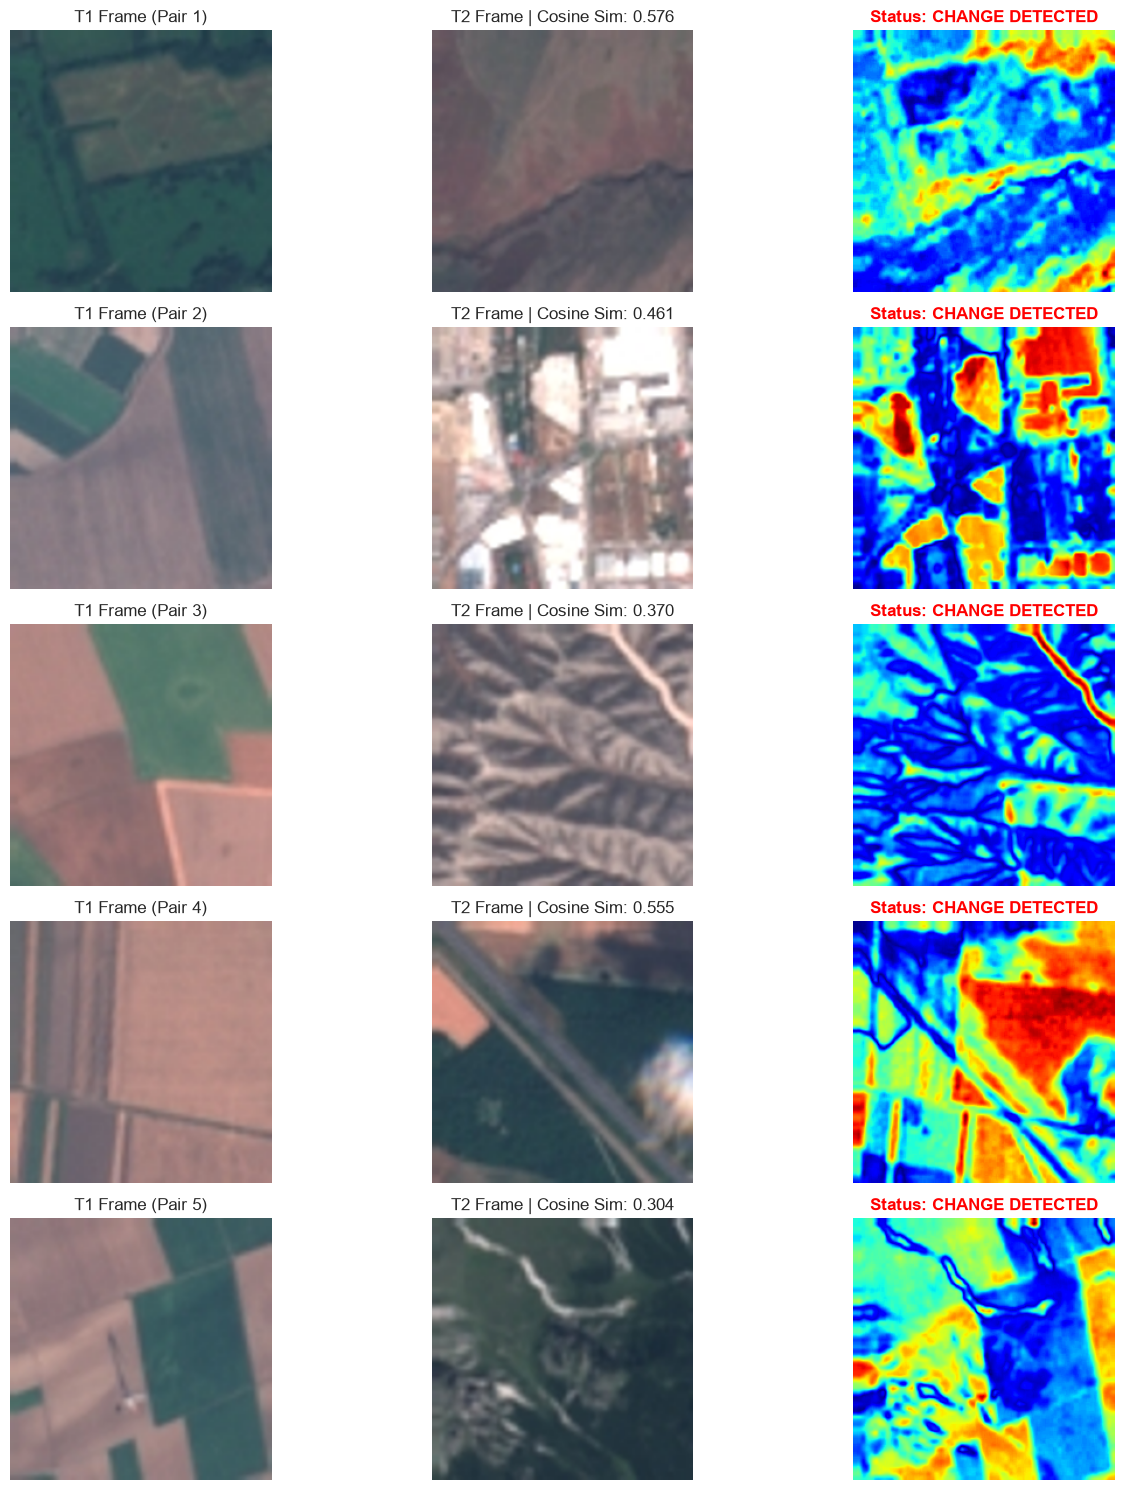

In [26]:
def generate_change_heatmap(img_path_t1, img_path_t2):
    """
    Computes a localized dimensional pixel variance array to isolate 
    and visualize regional landscape modifications[cite: 1].
    """
    img1 = Image.open(img_path_t1).resize((224, 224))
    img2 = Image.open(img_path_t2).resize((224, 224))
    
    arr1 = np.array(img1, dtype=np.float32)
    arr2 = np.array(img2, dtype=np.float32)
    
    # Absolute color channel differential mapped into a 2D scalar array
    diff = np.mean(np.abs(arr1 - arr2), axis=2)
    diff = (diff - diff.min()) / (diff.max() - diff.min() + 1e-8)
    
    return np.array(img1), np.array(img2), diff

# Plot 5 Sample Change Configurations Side-by-Side[cite: 1]
plt.figure(figsize=(14, 15))
actual_changed_indices = np.where(y_true == 1)[0][:5]

for idx, sample_idx in enumerate(actual_changed_indices):
    t1_path = t1_stream[sample_idx]
    t2_path = t2_stream[sample_idx]
    sim = similarities[sample_idx]
    
    im1, im2, heat = generate_change_heatmap(t1_path, t2_path)
    status_flag = "CHANGE DETECTED" if sim < optimal_similarity_threshold else "NO CHANGE"[cite: 1]
    
    plt.subplot(5, 3, idx*3 + 1)
    plt.imshow(im1)
    plt.title(f"T1 Frame (Pair {idx+1})")
    plt.axis('off')
    
    plt.subplot(5, 3, idx*3 + 2)
    plt.imshow(im2)
    plt.title(f"T2 Frame | Cosine Sim: {sim:.3f}")
    plt.axis('off')
    
    plt.subplot(5, 3, idx*3 + 3)
    plt.imshow(heat, cmap='jet')
    plt.title(f"Status: {status_flag}", color='red' if "DETECTED" in status_flag else 'green', fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

With the embedding extraction, cosine similarity engine, and threshold parameters verified, the entire analytical core of your computer vision engine is complete[cite: 1].

In **Step 5 (`app.py`)**, we will implement the **Geo-Dashboard** module[cite: 1]. We will move from standalone script tracking into an interactive local user application built using **Streamlit**[cite: 1]. It will accept custom double-image uploads, render land-use classification confidence scores, calculate embedding distance indices, and generate temporal maps in real-time[cite: 1].

# Step 5: Interactive Geo-Dashboard Application

This module implements **Module 3 — Geo-Dashboard** using **Streamlit**. The architecture runs entirely locally with zero internet dependencies once established[cite: 1]. 

It unifies all the distinct machine learning pipelines engineered across the previous modules:
1. **Land-Use Classification (Module 1)**: Infers land-use categories and target confidence probabilities for uploaded $T_1$ and $T_2$ tracking tiles[cite: 1].
2. **Temporal Embeddings (Module 2)**: Extracts 512-dimensional feature maps via the modified ResNet-18 backbone and evaluates pair-wise Cosine Similarity[cite: 1].
3. **Change Detection Mapping (Module 2)**: Automatically identifies structural changes if the similarity falls below the chosen operational threshold, outputting side-by-side verification maps[cite: 1].